In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pygplates
import numpy as np
from Plate_Circuit_Segmenter_aux import calculate_rot_matrix_from_euler_pole, search_for_plateIDs, interpolate_rotation_files
import os
import cartopy.crs as ccrs
import vaes_func as vfunc


In [2]:
#Reads in the dataframes
total_circuit_rot_file = r"C:\Users\Usuario\Documents\PMAGpythonRotation\rotations\Torsvik_Cocks_HybridRotationFile.rot"
col_names = ["plate_id", "age", "lat", "lon", "angle", "rel_plate"]
rot_data = np.loadtxt(r'C:\Users\Usuario\Documents\PMAGpythonRotation\rotations\Torsvik_Cocks_HybridRotationFile.rot', comments='!')
df = pd.read_csv(r"C:\Users\Usuario\Documents\PMAGpythonRotation\results\results.csv")


In [3]:
#Assign PlateIDs to each datapoint
#Cell for using the plate shape-files to automatically assign each point in the dataset to a plate ID.

from attr import define

rotation_model = pygplates.RotationModel(r'C:\Users\Usuario\Documents\PMAGpythonRotation\rotations\Torsvik_Cocks_HybridRotationFile.rot')
static_polygons_filename = r'C:\Users\Usuario\Documents\PMAGpythonRotation\rotations\CEED6_LAND.gpml'
input_points_filename = df

def assign_plate_id(static_polygons_filename, rotation_model, lat, lon):
    
    # Create a point geometry
    point = pygplates.PointOnSphere(lat, lon)
    
    # Create a feature and assign the geometry
    point_feature = pygplates.Feature()
    point_feature.set_geometry(point)
    
    # Partition the feature
    partitioned_features = pygplates.partition_into_plates(
        static_polygons_filename,
        rotation_model,
        [point_feature]
    )
    
    # Extract assigned plate ID
    if partitioned_features:
        return partitioned_features[0].get_reconstruction_plate_id()
    else:
        return None

for index, row in df.iterrows():
    lat = row['slat']
    lon = row['slon']
    assigned_plate = assign_plate_id(static_polygons_filename, rotation_model, lat, lon)
    df.at[index, 'assigned_plate_id'] = assigned_plate
    print(f"Point at ({lat}, {lon}) is assigned to plate ID: {assigned_plate}")

Point at (-32.2453, 28.5856) is assigned to plate ID: 701
Point at (-32.631, 20.145) is assigned to plate ID: 701
Point at (-32.78, 19.993) is assigned to plate ID: 701
Point at (-31.4, 27.3) is assigned to plate ID: 701
Point at (-30.4, 27.6) is assigned to plate ID: 701
Point at (-29.2, 27.3) is assigned to plate ID: 701
Point at (-28.5, 28.7) is assigned to plate ID: 701
Point at (-32.7, 20.6) is assigned to plate ID: 701
Point at (-32.1, 26.0) is assigned to plate ID: 701
Point at (-10.3, 34.6) is assigned to plate ID: 709
Point at (-18.0, 29.5) is assigned to plate ID: 701
Point at (-32.1, 19.6) is assigned to plate ID: 701
Point at (-29.2, 30.6) is assigned to plate ID: 701
Point at (-32.40733, 20.32633) is assigned to plate ID: 701
Point at (-32.8, 19.7) is assigned to plate ID: 701
Point at (-30.9, 29.4) is assigned to plate ID: 701
Point at (-7.33, 37.18) is assigned to plate ID: 709
Point at (-9.48, 33.67) is assigned to plate ID: 701
Point at (-9.2, 34.07) is assigned to pla

In [4]:
#Calculating Total Reconstruction Poles for each datapoint within df

ref_plate = 0

df['EPs'] = None
ref_poles,EPs = [],[]
for i in range(len(df)):
    EP = vfunc.tr_pole_2(df['assigned_plate_id'][i],ref_plate,rot_data,df['age'][i],multi_t=False)
    #print(df['assigned_plate_id'][i],ref_plate,df['age'][i])
    plat_0, plon_0 = -90,0     # reference pole is south geographic pole
    rlon,rlat=vfunc.pt_rot([EP[0],EP[1],-1*EP[2]],[plat_0],[plon_0])   # rotate with total reconstruction pole (inverted angle -> to rotate pole to coordinate system of plate)
    ref_poles.append([rlon,rlat]) # store longitude and latitude of reference pole
    EPs.append(EP)
    df.loc[i, ['EP_lat', 'EP_lon', 'EP_angle']] = EP




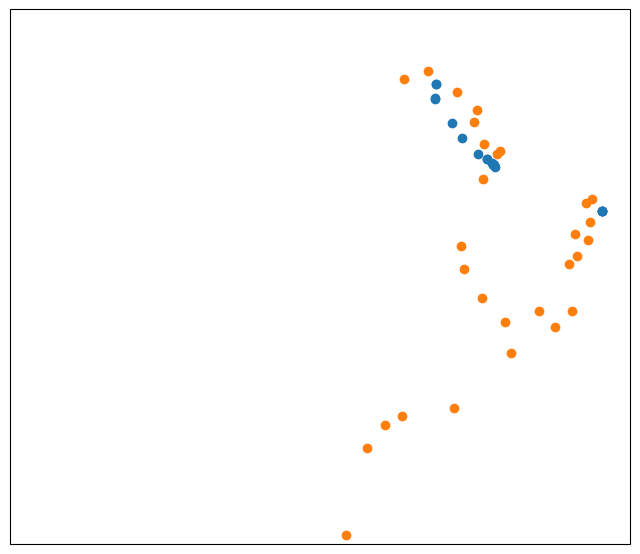

In [6]:
APWP = pd.read_excel(r"C:\Users\Usuario\Documents\PMAGpythonRotation\data\Global_APWP_Vaes_et_al_2023.xlsx", header=[0, 1])
APWP_lat = APWP['South Africa']['Latitude']
APWP_lon = APWP['South Africa']['Longitude']

ref_lons = [p[0] for p in ref_poles]
ref_lats = [p[1] for p in ref_poles]

fig = plt.figure(figsize=(8, 8))

#ax = plt.axes(projection=ccrs.Orthographic(60,-60))

ax = plt.axes(projection=ccrs.Mercator(central_longitude=100, max_latitude=0))

ax.scatter(ref_lons, ref_lats, transform=ccrs.Geodetic(), label="Rotated")

#ax.scatter(calculated_lons, calculated_lats, transform=ccrs.Geodetic(), label="Calculated")
#ax.scatter(180-orig_lons, -orig_lats, transform=ccrs.Geodetic(), label="Original")
ax.scatter(APWP_lon, APWP_lat, transform=ccrs.Geodetic(), label="APWP")
# ax.legend()

plt.show()

In [ ]:
APWP = pd.read_excel(r"C:\Users\rosso\Documents\PMAGpython\data\Global_APWP_Vaes_et_al_2023.xlsx", header=[0, 1])
APWP_lat = APWP['South Africa']['Latitude']
APWP_lon = APWP['South Africa']['Longitude']

In [ ]:
# Test with a known point
test_point = pygplates.PointOnSphere(pygplates.LatLonPoint(0, 0))  # Equator at prime meridian
test_rotation = rotation_model.get_rotation(100, 201)  # arbitrary age and plate

# Try both directions
rotated_1 = test_rotation * test_point
rotated_2 = test_rotation.get_inverse() * test_point

print("Direction 1:", rotated_1.to_lat_lon())
print("Direction 2:", rotated_2.to_lat_lon())